Prophet Model

Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']
Train length (vor Feiertag-Filter): 1400
Test length                       : 381
Train length (ohne Weihnachten/Silvester/Muttertag): 1390


08:50:21 - cmdstanpy - INFO - Chain [1] start processing
08:50:21 - cmdstanpy - INFO - Chain [1] done processing



--- METRIKEN (Prophet mit Features + Feiertags-Adjust) ---
MSE          : 8711409.01
RMSE         : 2951.51
R²           : 0.7794
MAE          : 2253.75
Relative MSE : 0.2425
MAPE         : 21.08%

Weihnachten im Testset (24.12.):


,Datum,Ist,Vorhersage
1453,2024-12-24,8.6,24.866667



Silvester im Testset (31.12.):


,Datum,Ist,Vorhersage
1460,2024-12-31,46032.2,30177.766667



Muttertag im Testset:


,Datum,Ist,Vorhersage
1591,2025-05-11,40176.1,29589.666667


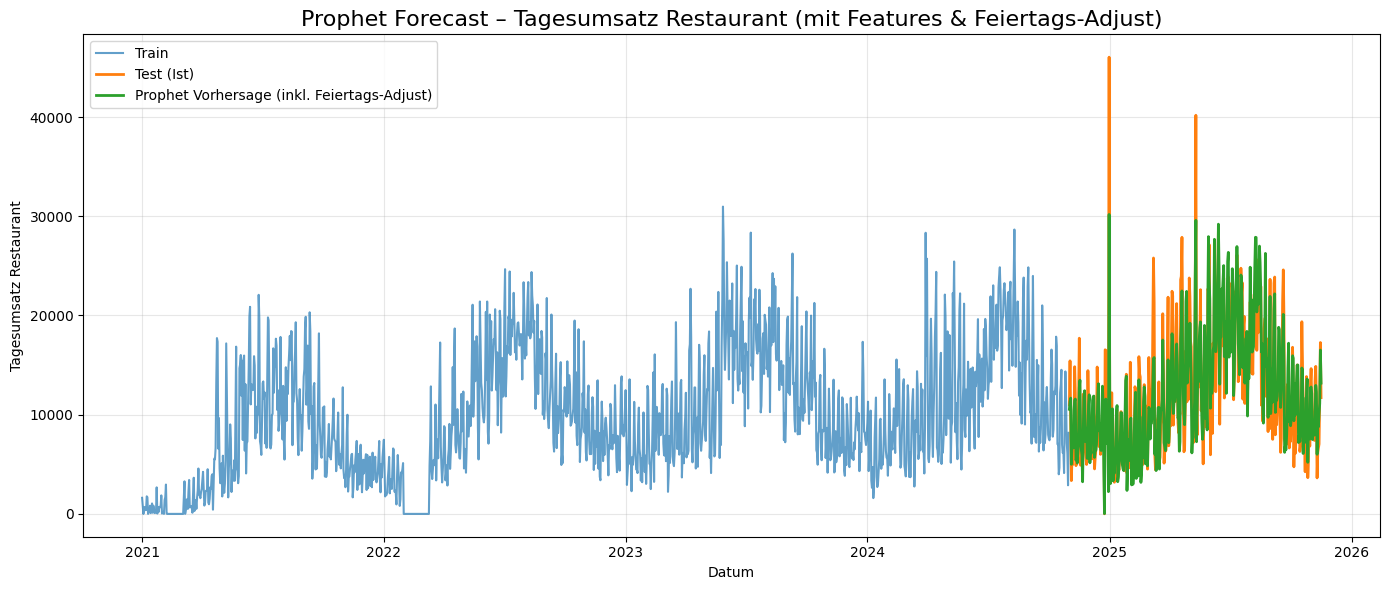

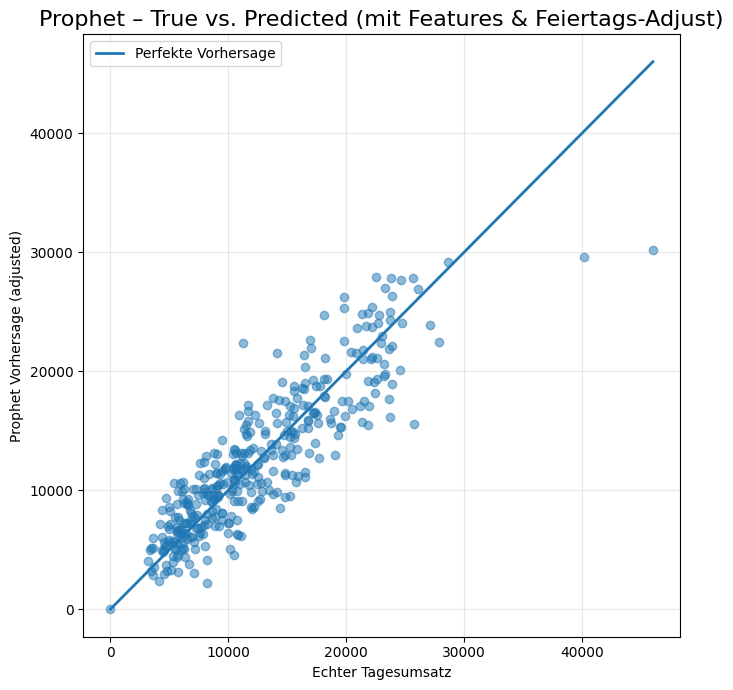

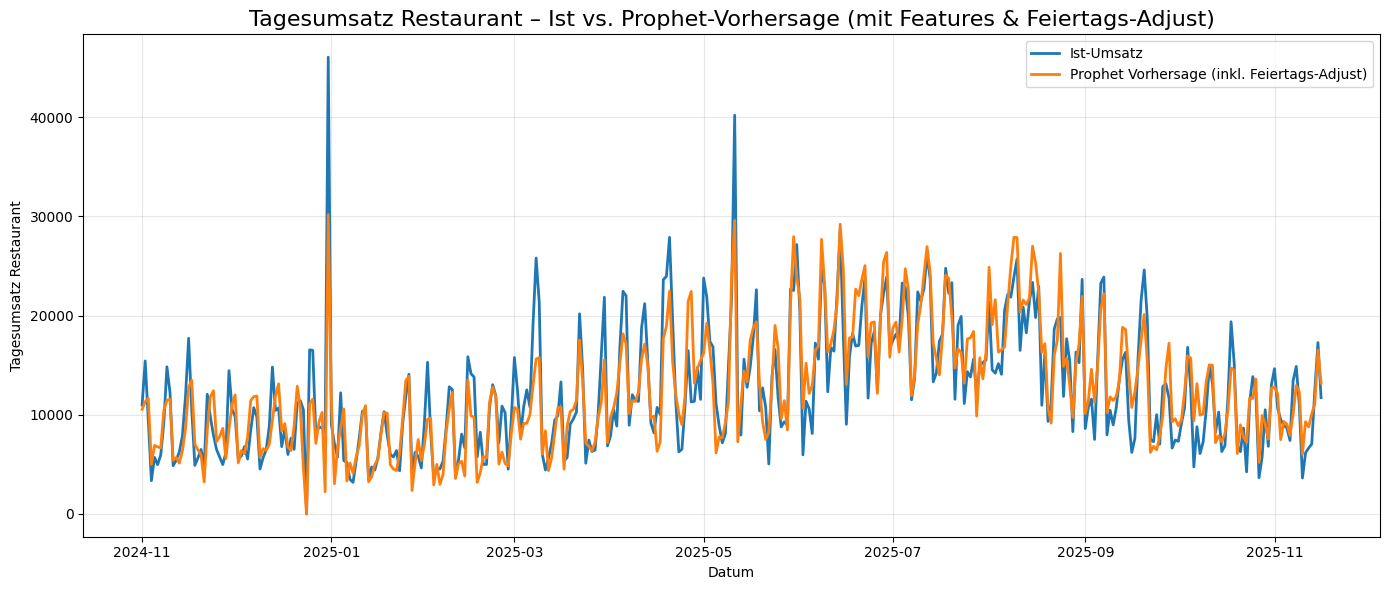

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)

# ============================================
# 1) Daten laden
# ============================================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Kopie mit Datum-Spalte für Feiertags-Helper
df_full = df.copy()

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

target_col = "Tagesumsatz Restaurant"

# ============================================
# 2) Zeitreihe mit allen Features vorbereiten
#    tägliche Frequenz + Lücken füllen
# ============================================
df = df.set_index("Datum").asfreq("D")
df = df.ffill().bfill()

# alle numerischen Spalten
num_cols = df.select_dtypes(include=["number"]).columns

# Ziel + Regressoren
regressors = [c for c in num_cols if c != target_col]

print("Zielvariable:", target_col)
print("Regressoren :", regressors)

# Prophet-DataFrame: ds, y, plus alle Regressoren
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})

# ============================================
# 3) Train/Test-Split (zeitbasiert)
# ============================================
split_date = pd.Timestamp("2024-11-01")
train = df_p[df_p["ds"] < split_date].copy()
test  = df_p[df_p["ds"] >= split_date].copy()

print("Train length (vor Feiertag-Filter):", len(train))
print("Test length                       :", len(test))

# ============================================
# 3b) Weihnachten, Silvester & Muttertag aus TRAINING entfernen
# ============================================
special_mask_train = train["ds"].apply(is_special_day)
train = train[~special_mask_train].copy()

print("Train length (ohne Weihnachten/Silvester/Muttertag):", len(train))

# ============================================
# 4) Prophet-Modell definieren und Regressoren hinzufügen
# ============================================
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.3,   # Standard 0.05 → mehr Trendflexibilität
)
m.add_seasonality(name='yearly_extra', period=365.25, fourier_order=15)

# alle numerischen Zusatzfeatures als Regressoren
for reg in regressors:
    m.add_regressor(reg)

# ============================================
# 5) Modell fitten (train enthält y + alle Regressoren)
# ============================================
m.fit(train[["ds", "y"] + regressors])

# ============================================
# 6) Zukunfts-DataFrame erzeugen (Train + Test Zeitraum)
# ============================================
future = m.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# future mit Regressoren befüllen (aus df_p)
future = future.merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_all = m.predict(future)

# Nur die Testperiode herausholen und auf dieselben ds wie im Test setzen
forecast_test = forecast_all[forecast_all["ds"] >= split_date].copy()
forecast_test = forecast_test.set_index("ds").loc[test["ds"]].reset_index()

# ============================================
# 7) Vorhersagen + Feiertags-Adjust
# ============================================
y_true = test["y"].values
y_pred = forecast_test["yhat"].values

# Kopie für angepasste Vorhersage
y_pred_adjusted = y_pred.copy()
test_dates = forecast_test["ds"].values  # entspricht test["ds"]

for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target_col
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target_col
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df_full,
            date_func=mothers_day,
            year=year,
            target_col=target_col
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# ============================================
# 8) Metriken (mit Feiertags-Adjust)
# ============================================
mse  = mean_squared_error(y_true, y_pred_adjusted)
rmse = mse ** 0.5
r2   = r2_score(y_true, y_pred_adjusted)
mae  = mean_absolute_error(y_true, y_pred_adjusted)

# Naive Baseline: Vortag als Prognose
full_series = df_p.set_index("ds")["y"]
test_series = full_series.loc[test["ds"]]
y_naive = test_series.shift(1).bfill().values

mse_naive = mean_squared_error(y_true, y_naive)
relative_MSE = mse / mse_naive  # hier kannst du auch mse mit mse_model/MSE_naive ersetzen

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_true, y_pred_adjusted)

print("\n--- METRIKEN (Prophet mit Features + Feiertags-Adjust) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ============================================
# 9) Ergebnis-DataFrame
# ============================================
results_prophet = pd.DataFrame({
    "Datum": test["ds"],
    "Ist": y_true,
    "Vorhersage": y_pred_adjusted
})

# Am Schluss: explizit Weihnachten, Silvester & Muttertag anzeigen
print("\nWeihnachten im Testset (24.12.):")
display(results_prophet[
    (results_prophet["Datum"].dt.month == 12) &
    (results_prophet["Datum"].dt.day == 24)
])

print("\nSilvester im Testset (31.12.):")
display(results_prophet[
    (results_prophet["Datum"].dt.month == 12) &
    (results_prophet["Datum"].dt.day == 31)
])

print("\nMuttertag im Testset:")
results_mothers = results_prophet[
    results_prophet["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers)

# ============================================
# 10) Zeitreihen-Plot: Train, Test, Prophet-Vorhersage (adjusted)
# ============================================
plt.figure(figsize=(14,6))
plt.plot(train["ds"], train["y"], label="Train", alpha=0.7)
plt.plot(test["ds"], test["y"], label="Test (Ist)", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Prophet Forecast – Tagesumsatz Restaurant (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 11) Scatter-Plot: True vs. Predicted (adjusted)
# ============================================
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred_adjusted, alpha=0.5)

min_val = min(y_true.min(), y_pred_adjusted.min())
max_val = max(y_true.max(), y_pred_adjusted.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("Prophet – True vs. Predicted (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Prophet Vorhersage (adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 12) Kompakter Test-Plot: Ist vs. Prophet-Vorhersage (adjusted)
# ============================================
plt.figure(figsize=(14,6))
plt.plot(results_prophet["Datum"], results_prophet["Ist"],
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. Prophet-Vorhersage (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
